In [1]:
import os
import sys
from pathlib import Path

library_path = os.path.abspath('../../src')
if library_path not in sys.path:
    sys.path.append(library_path)
library_path = Path(library_path)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score

DATA_PATH = library_path.parent / "data"
PLOTS_PATH = library_path.parent / "plots"
PLOTS_PATH.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

In [3]:
df = pd.read_csv(DATA_PATH / "wrangled_data.csv", low_memory=False)

pre_2020    = df[df["dataset"].isin(["HSE 2017", "HSE 2018", "HSE 2019"])].copy()
daphnie_23  = df[df["dataset"] == "DAPHNIE 2023"].copy()
daphnie_24  = df[df["dataset"] == "DAPHNIE 2024"].copy()

print(f"Pre-2020 HSE:  n = {len(pre_2020):,}")
print(f"DAPHNIE 2023:  n = {len(daphnie_23):,}")
print(f"DAPHNIE 2024:  n = {len(daphnie_24):,}")

Pre-2020 HSE:  n = 24,374
DAPHNIE 2023:  n = 1,657
DAPHNIE 2024:  n = 5,237


## Density Ratio Estimation

### Rationale

We want to re-weight each DAPHNIE observation so that its weighted distribution matches
pre-2020 HSE. The weight for observation $i$ is the density ratio:

$$w(x_i) = \frac{P_{\text{HSE}}(x_i)}{P_{\text{DAPHNIE}}(x_i)}$$

**Classifier-based estimation.** Pool DAPHNIE (label 0) and pre-2020 HSE (label 1) and
train a binary classifier. With `class_weight='balanced'`, the classifier equalises the
prior on both classes, so Bayes' theorem gives:

$$w(x) = \frac{\hat{p}(x)}{1 - \hat{p}(x)}$$

where $\hat{p}(x) = P(\text{HSE} \mid x)$ is the predicted probability. No sample-size
correction is needed because the balanced weighting already equalises the priors.

Weights are normalized to mean 1 and clipped at the 99th percentile to prevent a small
number of extreme values from dominating the reweighted estimates.

### Classifiers

- **Logistic regression** — primary model. Interpretable (coefficients show which
  variables drive the shift), well-calibrated, and directly analogous to propensity
  score weighting. Requires median imputation for missing values.
- **Gradient boosting** (`HistGradientBoostingClassifier`) — robustness check. Captures
  non-linear interactions and handles missing values natively. If AUC is substantially
  higher than logistic regression, residual non-linearity in the density ratio should be
  investigated.

### Evaluation

Cross-validated AUC measures how well the classifier separates the two distributions.
An AUC of 0.5 means the distributions are indistinguishable; AUC near 1 means they are
very different. After reweighting, we re-run the SMD comparison — all variables should
fall below $|\text{SMD}| = 0.1$ if the reweighting worked.

In [4]:
# Confirmed clean predictors (Apr 2026 data audit).
# Excluded pending PI decision: obese (measurement shift), resp/skin (missing HSE 2019),
#   smoke_ever (within-HSE inconsistency), alcohol_yr (skip logic + HSE 2022 missing),
#   paVig/paMod (DAPHNIE-only).
# Outcomes (srh, EQ-5D dims, ill_dis, meds_num, sat, edu_cat) removed from predictor set.
FEATURES = [
    "Sex", "age7cat",
    "eth4cat_Asian", "eth4cat_Black", "eth4cat_Others", "eth4cat_White",
    "emp_cat_Employed", "emp_cat_Other (Sick/Home/etc)", "emp_cat_Retired",
    "emp_cat_Student", "emp_cat_Unemployed",
    "diabetes", "smoke_ecig",
]
FEATURES = [f for f in FEATURES if f in df.columns]
print(f"Features ({len(FEATURES)}):")
print(FEATURES)

Features (13):
['Sex', 'age7cat', 'eth4cat_Asian', 'eth4cat_Black', 'eth4cat_Others', 'eth4cat_White', 'emp_cat_Employed', 'emp_cat_Other (Sick/Home/etc)', 'emp_cat_Retired', 'emp_cat_Student', 'emp_cat_Unemployed', 'diabetes', 'smoke_ecig']


In [5]:
def weighted_mean(series, weights):
    mask = series.notna() & weights.notna() & (weights > 0)
    if mask.sum() == 0:
        return np.nan
    s, w = series[mask], weights[mask]
    return np.average(s, weights=w)


def weighted_var(series, weights):
    mask = series.notna() & weights.notna() & (weights > 0)
    if mask.sum() < 2:
        return np.nan
    s, w = series[mask], weights[mask]
    mu = np.average(s, weights=w)
    return np.average((s - mu) ** 2, weights=w)


def compute_smd(source_series, source_weights, target_series, target_weights):
    mu_s = weighted_mean(source_series, source_weights)
    mu_t = weighted_mean(target_series, target_weights)
    if np.isnan(mu_s) or np.isnan(mu_t):
        return np.nan
    var_s = weighted_var(source_series, source_weights)
    var_t = weighted_var(target_series, target_weights)
    if np.isnan(var_s) or np.isnan(var_t):
        return np.nan
    pooled_sd = np.sqrt((var_s + var_t) / 2)
    if pooled_sd == 0:
        return np.nan
    return (mu_s - mu_t) / pooled_sd

In [6]:
def fit_classifiers(daphnie_df, hse_df, features):
    """
    Pool DAPHNIE (label=0) and HSE (label=1), fit logistic regression and gradient
    boosting classifiers, return 5-fold CV AUC and fitted models.
    """
    src = daphnie_df[features].copy().assign(_label=0)
    tgt = hse_df[features].copy().assign(_label=1)
    pooled = pd.concat([src, tgt], ignore_index=True)

    X, y = pooled[features], pooled["_label"]
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    lr = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("clf",     LogisticRegression(
            max_iter=1000, class_weight="balanced", random_state=42
        )),
    ])
    hgb = HistGradientBoostingClassifier(
        max_iter=300, class_weight="balanced", random_state=42
    )

    auc_lr  = cross_val_score(lr,  X, y, cv=cv, scoring="roc_auc")
    auc_hgb = cross_val_score(hgb, X, y, cv=cv, scoring="roc_auc")

    lr.fit(X, y)
    hgb.fit(X, y)

    return lr, hgb, auc_lr, auc_hgb, X, y


def compute_weights(clf, daphnie_X, clip_percentile=99):
    """
    Given a balanced classifier, compute density ratio weights for DAPHNIE observations.
    w(x) = p_hat / (1 - p_hat), normalized to mean 1, clipped at clip_percentile.
    """
    p_hat = clf.predict_proba(daphnie_X)[:, 1]  # P(HSE | x)
    eps = 1e-8
    w = p_hat / (1 - p_hat + eps)
    w = w / w.mean()                            # normalize to mean 1

    clip_val = np.percentile(w, clip_percentile)
    n_clipped = (w > clip_val).sum()
    w = np.clip(w, 0, clip_val)
    w = w / w.mean()                            # re-normalize after clipping

    n_eff = w.sum() ** 2 / (w ** 2).sum()
    return w, clip_val, n_clipped, n_eff

In [8]:
waves = {
    "DAPHNIE 2023": daphnie_23,
    "DAPHNIE 2024": daphnie_24,
}

results = {}

for wave, daphnie_df in waves.items():
    n_src, n_tgt = len(daphnie_df), len(pre_2020)
    print(f"\n{'='*60}")
    print(f"{wave}  (n={n_src:,})  vs  pre-2020 HSE  (n={n_tgt:,})")
    print(f"Class ratio  DAPHNIE:HSE = 1:{n_tgt/n_src:.1f}")
    print(f"{'='*60}")

    lr, hgb, auc_lr, auc_hgb, X, y = fit_classifiers(daphnie_df, pre_2020, FEATURES)

    print(f"  Logistic regression  AUC = {auc_lr.mean():.3f}  (± {auc_lr.std():.3f})")
    print(f"  Gradient boosting    AUC = {auc_hgb.mean():.3f}  (± {auc_hgb.std():.3f})")

    # predict_proba runs through the full pipeline (imputer → scaler → clf)
    # using the pooled statistics from fit — no manual imputation needed
    X_daphnie = daphnie_df[FEATURES]

    w_lr,  clip_lr,  n_clip_lr,  n_eff_lr  = compute_weights(lr,  X_daphnie)
    w_hgb, clip_hgb, n_clip_hgb, n_eff_hgb = compute_weights(hgb, X_daphnie)

    print(f"\n  Logistic regression weights:")
    print(f"    Clipped at 99th pct = {clip_lr:.2f}  ({n_clip_lr} obs, {100*n_clip_lr/n_src:.1f}%)")
    print(f"    Effective n = {n_eff_lr:.0f} / {n_src}  ({100*n_eff_lr/n_src:.1f}%)")

    print(f"\n  Gradient boosting weights:")
    print(f"    Clipped at 99th pct = {clip_hgb:.2f}  ({n_clip_hgb} obs, {100*n_clip_hgb/n_src:.1f}%)")
    print(f"    Effective n = {n_eff_hgb:.0f} / {n_src}  ({100*n_eff_hgb/n_src:.1f}%)")

    results[wave] = {
        "df":      daphnie_df.copy(),
        "w_lr":    w_lr,
        "w_hgb":   w_hgb,
        "lr":      lr,
        "hgb":     hgb,
        "auc_lr":  auc_lr,
        "auc_hgb": auc_hgb,
    }


DAPHNIE 2023  (n=1,657)  vs  pre-2020 HSE  (n=24,374)
Class ratio  DAPHNIE:HSE = 1:14.7
  Logistic regression  AUC = 0.719  (± 0.009)
  Gradient boosting    AUC = 0.796  (± 0.014)

  Logistic regression weights:
    Clipped at 99th pct = 6.37  (16 obs, 1.0%)
    Effective n = 672 / 1657  (40.6%)

  Gradient boosting weights:
    Clipped at 99th pct = 3.78  (16 obs, 1.0%)
    Effective n = 949 / 1657  (57.2%)

DAPHNIE 2024  (n=5,237)  vs  pre-2020 HSE  (n=24,374)
Class ratio  DAPHNIE:HSE = 1:4.7
  Logistic regression  AUC = 0.586  (± 0.004)
  Gradient boosting    AUC = 0.638  (± 0.008)

  Logistic regression weights:
    Clipped at 99th pct = 1.49  (47 obs, 0.9%)
    Effective n = 4691 / 5237  (89.6%)

  Gradient boosting weights:
    Clipped at 99th pct = 2.36  (51 obs, 1.0%)
    Effective n = 4165 / 5237  (79.5%)


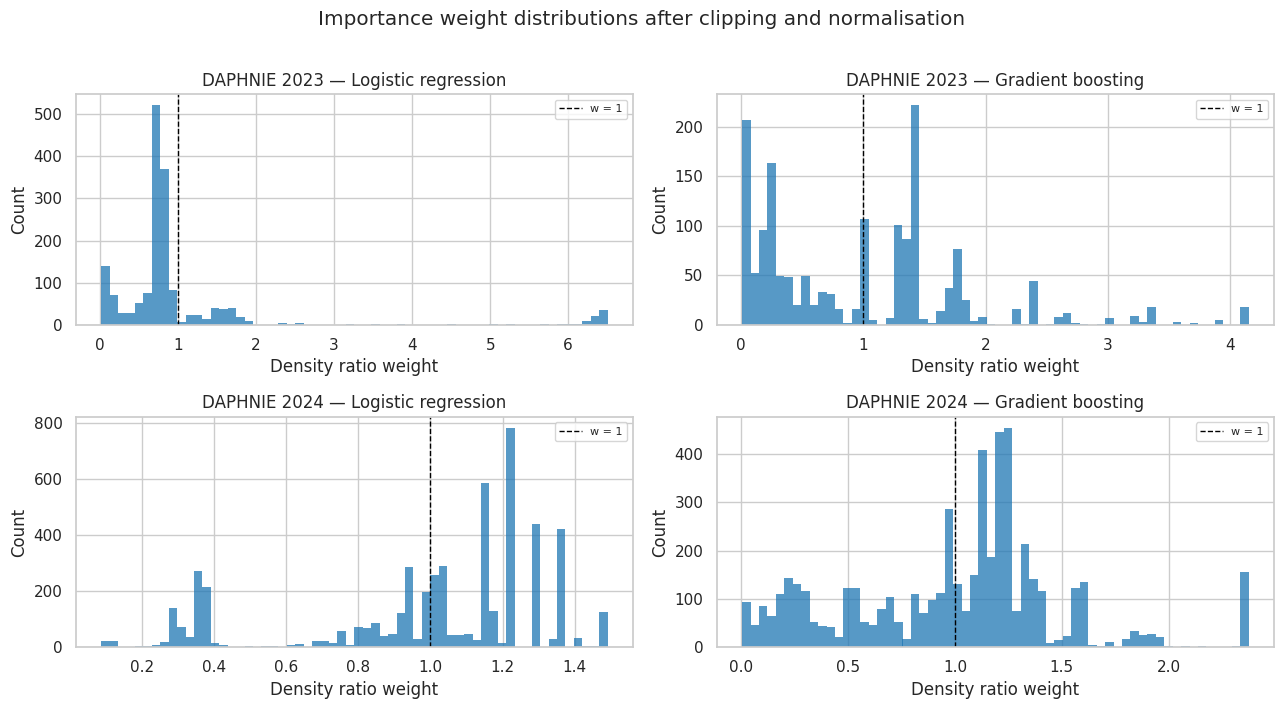

In [9]:
# Weight distribution plots — one row per DAPHNIE wave, LR vs HGB side by side
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharey=False)

for row, (wave, res) in enumerate(results.items()):
    for col, (label, w) in enumerate([("Logistic regression", res["w_lr"]),
                                       ("Gradient boosting",   res["w_hgb"])]):
        ax = axes[row, col]
        ax.hist(w, bins=60, color="#1f77b4", edgecolor="none", alpha=0.75)
        ax.axvline(1.0, color="black", linewidth=1.0, linestyle="--", label="w = 1")
        ax.set_title(f"{wave} — {label}")
        ax.set_xlabel("Density ratio weight")
        ax.set_ylabel("Count")
        ax.legend(fontsize=8)

fig.suptitle("Importance weight distributions after clipping and normalisation", y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_PATH / "density_ratio_weight_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

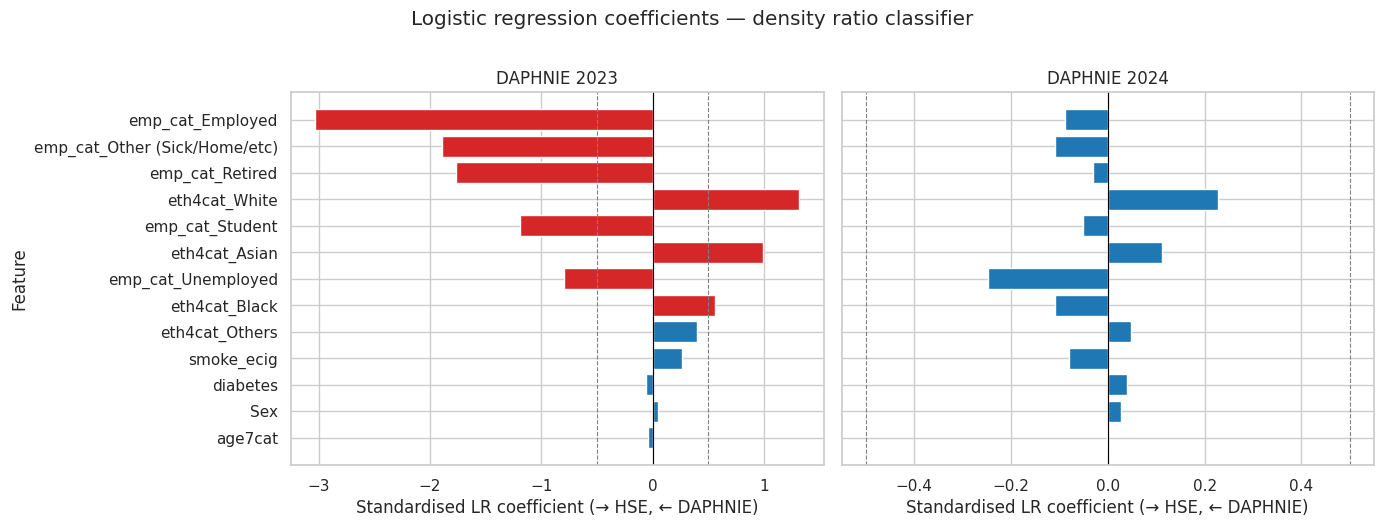


DAPHNIE 2023 — LR coefficients (standardised):


,coefficient,|coefficient|
emp_cat_Employed,-3.030,3.030
emp_cat_Other (Sick/Home/etc),-1.894,1.894
emp_cat_Retired,-1.766,1.766
eth4cat_White,1.317,1.317
emp_cat_Student,-1.195,1.195
eth4cat_Asian,0.994,0.994
emp_cat_Unemployed,-0.797,0.797
eth4cat_Black,0.559,0.559
eth4cat_Others,0.401,0.401
smoke_ecig,0.261,0.261



DAPHNIE 2024 — LR coefficients (standardised):


,coefficient,|coefficient|
emp_cat_Unemployed,-0.246,0.246
eth4cat_White,0.228,0.228
eth4cat_Asian,0.111,0.111
emp_cat_Other (Sick/Home/etc),-0.110,0.110
eth4cat_Black,-0.109,0.109
emp_cat_Employed,-0.088,0.088
smoke_ecig,-0.080,0.080
emp_cat_Student,-0.052,0.052
eth4cat_Others,0.049,0.049
diabetes,0.039,0.039


In [10]:
# LR coefficient inspection — which features drive the separation?
# Coefficients are on the standardised scale, so magnitudes are directly comparable.
# Positive = feature pushes towards HSE (label=1); negative = pushes towards DAPHNIE.

fig, axes = plt.subplots(1, 2, figsize=(14, max(5, len(FEATURES) * 0.4)), sharey=True)

for ax, (wave, res) in zip(axes, results.items()):
    clf  = res["lr"].named_steps["clf"]
    coef = pd.Series(clf.coef_[0], index=FEATURES).sort_values(key=abs)
    colors = ["#d62728" if abs(v) > 0.5 else "#1f77b4" for v in coef]
    ax.barh(coef.index, coef.values, color=colors)
    ax.axvline(0,    color="black", linewidth=0.8)
    ax.axvline( 0.5, color="grey",  linewidth=0.8, linestyle="--")
    ax.axvline(-0.5, color="grey",  linewidth=0.8, linestyle="--")
    ax.set_title(f"{wave}")
    ax.set_xlabel("Standardised LR coefficient (→ HSE, ← DAPHNIE)")

axes[0].set_ylabel("Feature")
fig.suptitle("Logistic regression coefficients — density ratio classifier", y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_PATH / "lr_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

# Table
for wave, res in results.items():
    clf  = res["lr"].named_steps["clf"]
    tbl = (
        pd.DataFrame({
            "coefficient":   clf.coef_[0],
            "|coefficient|": np.abs(clf.coef_[0]),
        }, index=FEATURES)
        .sort_values("|coefficient|", ascending=False)
    )
    print(f"\n{wave} — LR coefficients (standardised):")
    display(tbl.round(3))

In [11]:
# Balance check: SMD before and after reweighting
hse_wt = pre_2020["wt_int"].fillna(1.0)

balance = {}
for wave, res in results.items():
    ddf = res["df"]
    svy_wt = ddf["svy_wt"].fillna(1.0)

    smds = {}
    for col in FEATURES:
        smds[col] = {
            "Before (LR)": compute_smd(ddf[col], svy_wt, pre_2020[col], hse_wt),
            "After (LR)":  compute_smd(ddf[col], svy_wt * res["w_lr"],  pre_2020[col], hse_wt),
            "After (HGB)": compute_smd(ddf[col], svy_wt * res["w_hgb"], pre_2020[col], hse_wt),
        }
    balance[wave] = pd.DataFrame(smds).T

for wave, tbl in balance.items():
    print(f"\n{wave} — covariate balance (SMD):")
    display(
        tbl.dropna(how="all")
        .sort_values("Before (LR)", key=abs, ascending=False)
        .round(3)
    )


DAPHNIE 2023 — covariate balance (SMD):


,Before (LR),After (LR),After (HGB)
emp_cat_Retired,-0.521,0.150,-0.597
emp_cat_Employed,0.429,-0.077,0.364
eth4cat_White,-0.314,0.003,0.022
smoke_ecig,-0.251,-0.045,0.019
eth4cat_Others,0.227,-0.000,0.015
emp_cat_Student,-0.140,-0.103,-0.025
emp_cat_Unemployed,-0.081,-0.025,-0.039
eth4cat_Black,0.075,-0.018,-0.010
emp_cat_Other (Sick/Home/etc),0.063,0.012,0.104
eth4cat_Asian,-0.059,0.014,-0.031



DAPHNIE 2024 — covariate balance (SMD):


,Before (LR),After (LR),After (HGB)
eth4cat_Black,0.245,-0.018,-0.031
emp_cat_Unemployed,0.237,-0.014,-0.013
eth4cat_White,-0.166,0.068,0.084
emp_cat_Employed,-0.086,-0.071,-0.046
emp_cat_Student,-0.061,-0.112,-0.098
smoke_ecig,0.060,-0.037,-0.028
emp_cat_Other (Sick/Home/etc),0.052,0.027,0.001
Sex,0.048,0.078,0.081
age7cat,0.041,0.198,0.176
emp_cat_Retired,-0.028,0.128,0.113


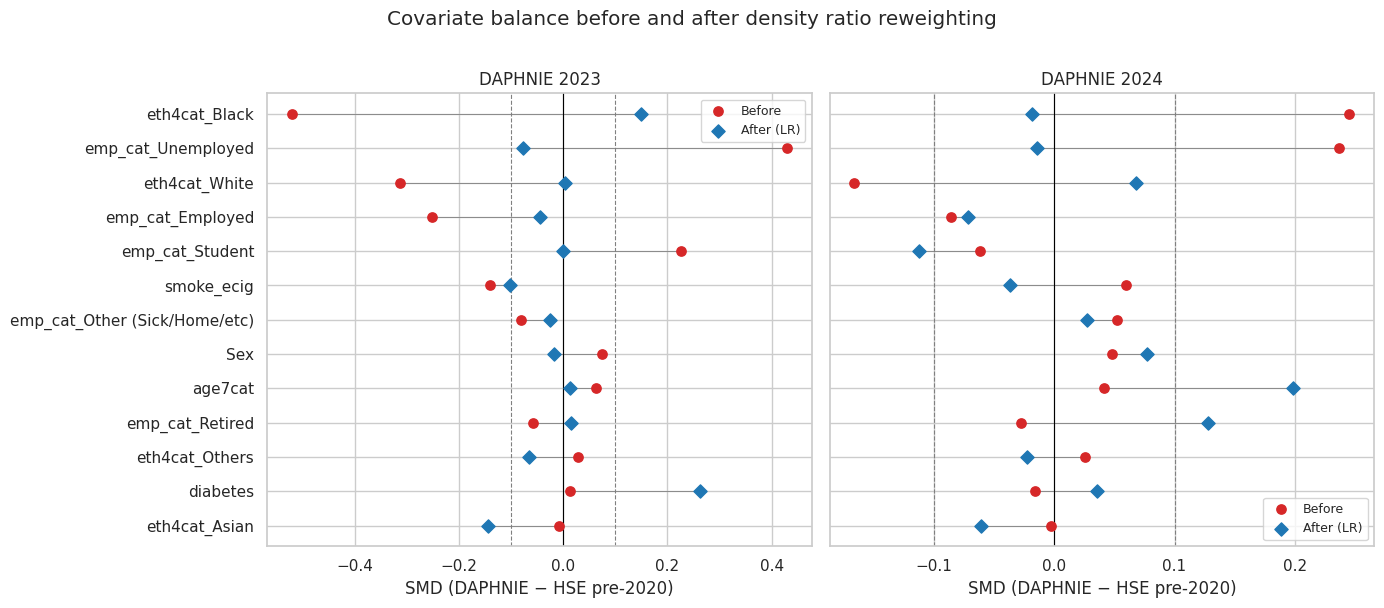

DAPHNIE 2023: imbalanced variables  before=6  after LR=4  after HGB=5
DAPHNIE 2024: imbalanced variables  before=3  after LR=3  after HGB=2


In [12]:
# Love plot — before vs after (LR) for each DAPHNIE wave
fig, axes = plt.subplots(1, 2, figsize=(14, max(6, len(FEATURES) * 0.45)), sharey=True)

for ax, (wave, tbl) in zip(axes, balance.items()):
    tbl_plot = tbl.dropna(subset=["Before (LR)", "After (LR)"]).copy()
    order = tbl_plot["Before (LR)"].abs().sort_values().index

    y_pos = np.arange(len(order))
    before = tbl_plot.loc[order, "Before (LR)"]
    after  = tbl_plot.loc[order, "After (LR)"]

    ax.scatter(before, y_pos, color="#d62728", zorder=3, s=45, label="Before")
    ax.scatter(after,  y_pos, color="#1f77b4", zorder=3, s=45, marker="D", label="After (LR)")
    for i, (b, a) in enumerate(zip(before, after)):
        ax.plot([b, a], [i, i], color="grey", linewidth=0.6, zorder=2)

    ax.axvline(0,    color="black", linewidth=0.8)
    ax.axvline( 0.1, color="grey",  linewidth=0.8, linestyle="--")
    ax.axvline(-0.1, color="grey",  linewidth=0.8, linestyle="--")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(order)
    ax.set_xlabel("SMD (DAPHNIE − HSE pre-2020)")
    ax.set_title(wave)
    ax.legend(fontsize=9)

fig.suptitle("Covariate balance before and after density ratio reweighting", y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_PATH / "balance_pre_post_reweighting.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary: how many variables still exceed |SMD| > 0.1 after reweighting?
for wave, tbl in balance.items():
    n_before = tbl["Before (LR)"].abs().gt(0.1).sum()
    n_after_lr  = tbl["After (LR)"].abs().gt(0.1).sum()
    n_after_hgb = tbl["After (HGB)"].abs().gt(0.1).sum()
    print(f"{wave}: imbalanced variables  before={n_before}  after LR={n_after_lr}  after HGB={n_after_hgb}")